<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A temperature forecasting example

In [2]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-09-04 04:04:13--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.133.0, 16.15.244.94, 16.15.223.191, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.133.0|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  67.5MB/s    in 0.2s    

2026-09-04 04:04:13 (67.5 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [3]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [4]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]

    # We store column 1 in the temperature array.
    temperature[i] = values[1]

    # We store all columns (including the temperature) in the raw_data array.
    raw_data[i, :] = values[:]

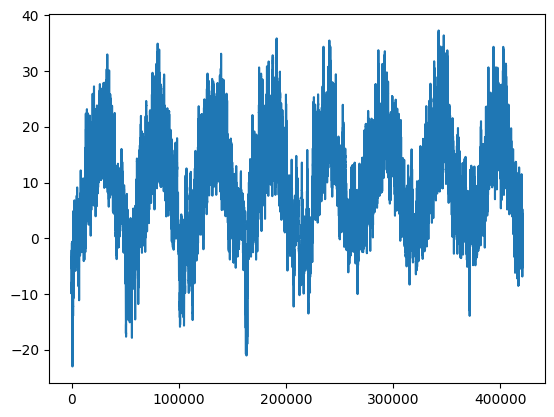

In [5]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

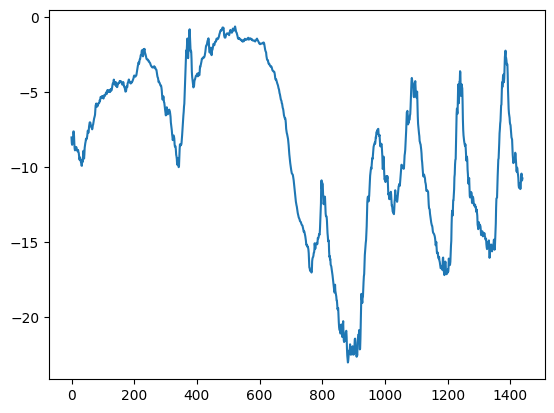

In [6]:
plt.plot(range(1440), temperature[:1440])

In [7]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

# Note: 50% for training, 25% for validation, and 25% for testing.
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [8]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [9]:
import numpy as np
import keras

# Generate an array of sorted integers from 0 to 9.
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    # The sequences we generate will be sampled from [0 2 3 4 5 6].
    data=int_sequence[:-3],

    # The target for the sequence that starts at data[N] will be data[N + 3]
    targets=int_sequence[3:],

    # The sequences will be 3 steps long.
    sequence_length=3,

    # The sequences will be batched in batches of size 2.
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [10]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [11]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [12]:
# A commonsense, non-machine-learning baseline

In [13]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0

    for samples, targets in dataset:
        # The temperature feature is at column 1, so `samples[:, -1, 1] is the last
        # temperature measurement in the input sequence. Recall that we normalized our features
        # to retrieve a temperature in Celsiums degrees, we need to un-normalized it, by
        # multiplying it by the standard deviation and adding back the mean.
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]

    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


In [14]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    # We use a callback to save the best-performing model.
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

# Reloads the best model and evaluates it on the test data
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - loss: 12.1061 - mae: 2.6823 - val_loss: 10.4520 - val_mae: 2.5498
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - loss: 8.4693 - mae: 2.2881 - val_loss: 10.7684 - val_mae: 2.5911
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.7930 - mae: 2.1956 - val_loss: 10.6644 - val_mae: 2.5803
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 7.3463 - mae: 2.1331 - val_loss: 11.1373 - val_mae: 2.6334
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 7.0203 - mae: 2.0865 - val_loss: 11.5832 - val_mae: 2.6887
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - loss: 6.8023 - mae: 2.0524 - val_loss: 11.4133 - val_mae: 2.6599
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 6.5977 - mae: 2.0208 - val_loss: 12.4865 - val_mae: 2.7899
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 6.4633 - mae: 2.0014 - val_loss: 11.5278 - val_mae: 2.6683
Epoch 9/10
819/819 ━━━━━━━━━━━━

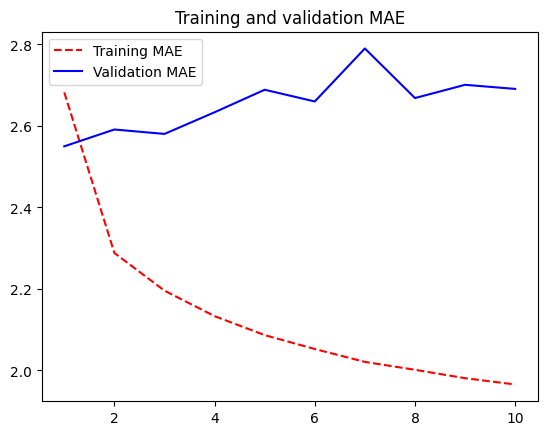

In [15]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [16]:
# Try a 1D convolutional model

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")

print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 90s 107ms/step - loss: 21.4406 - mae: 3.6185 - val_loss: 14.8933 - val_mae: 3.0378
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 86s 105ms/step - loss: 14.0692 - mae: 2.9748 - val_loss: 14.4076 - val_mae: 3.0105
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 108ms/step - loss: 12.6352 - mae: 2.8150 - val_loss: 14.3064 - val_mae: 2.9943
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 140s 106ms/step - loss: 11.8249 - mae: 2.7232 - val_loss: 14.4068 - val_mae: 3.0112
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 106ms/step - loss: 11.2560 - mae: 2.6547 - val_loss: 14.0409 - val_mae: 2.9531
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 143s 108ms/step - loss: 10.8542 - mae: 2.6036 - val_loss: 13.8475 - val_mae: 2.9360
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 88s 107ms/step - loss: 10.4704 - mae: 2.5572 - val_loss: 13.8555 - val_mae: 2.9257
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 89s 107ms/step - loss: 10.1516 - mae: 2.5178 - val_loss: 13.9453 - val_mae: 2.9310
Epoch 9/10
819

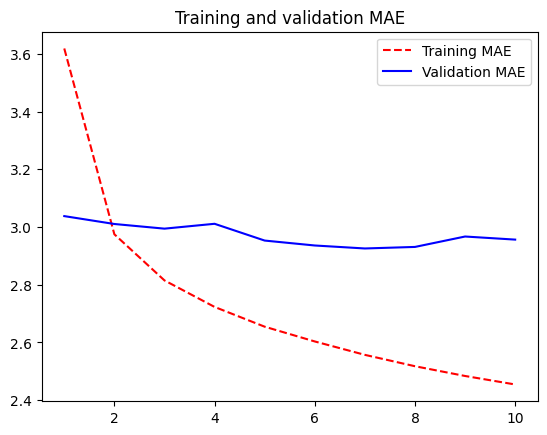

In [18]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [19]:
# Reccurrent neural networks

In [20]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.LSTM(16)(inputs)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)

model = keras.models.load_model("jena_lstm.keras")

print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 109s 131ms/step - loss: 47.9873 - mae: 5.1011 - val_loss: 18.4022 - val_mae: 3.1920
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 141s 130ms/step - loss: 14.9813 - mae: 2.9329 - val_loss: 11.8724 - val_mae: 2.6395
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 110s 134ms/step - loss: 11.3767 - mae: 2.6125 - val_loss: 10.3116 - val_mae: 2.4869
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 109s 133ms/step - loss: 10.3618 - mae: 2.5039 - val_loss: 9.4131 - val_mae: 2.3732
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 108s 132ms/step - loss: 9.5880 - mae: 2.4080 - val_loss: 9.2601 - val_mae: 2.3684
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 110s 134ms/step - loss: 9.0870 - mae: 2.3475 - val_loss: 9.5710 - val_mae: 2.4117
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 108s 131ms/step - loss: 8.8028 - mae: 2.3178 - val_loss: 10.3150 - val_mae: 2.4519
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 141s 130ms/step - loss: 8.5242 - mae: 2.2837 - val_loss: 9.3685 - val_mae: 2.3921
Epoch 9/10
819/8

In [21]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - loss: 10.5726 - mae: 2.5631
Test MAE: 2.56


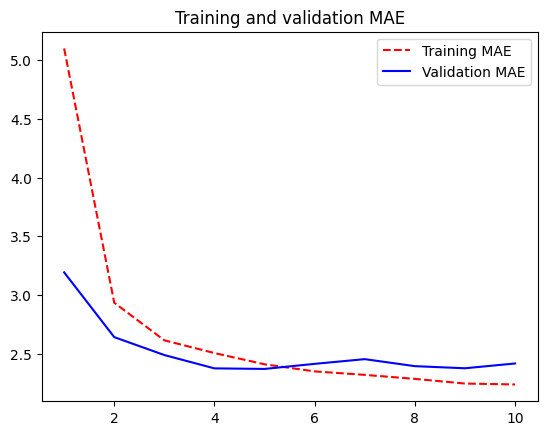

In [22]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [23]:
import numpy as np

# Number of timesteps in the input sequence
timesteps = 100

# Dimensionality of the input feature space
input_features = 32

# Dimensionality of the output feature space
output_features = 64

# Input data: random noise for the sake of the example
inputs = np.random.random((timesteps, input_features))

# Initial state: an all-zero vector
state_t = np.zeros((output_features,))

# Creates random weight matrices
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []

# input_t is a vector of shape (input_features,).
for input_t in inputs:
    # Combines the input with the current state (the previous output)
    # to obtain the current output. We use tanh to add nonlinearity
    # (we could use any other activation function).
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)

    # Stores this output in a list
    successive_outputs.append(output_t)

    # Updates the state of the network for the next timestep
    state_t = output_t

# The final output is a rank-2 tensor of shape (timesteps, output_features).
final_output_sequence = np.concatenate(successive_outputs, axis=0)

In [24]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))

# Note that return_sequences=False is the default
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [25]:
nume_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))

# Sets return_sequences to True
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [26]:
inputs = keras.Input(shape=(steps, num_features))

x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)

outputs = layers.SimpleRNN(16)(x)

In [27]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)

# To regularize the Dense layer, we also add a Dropout layer after the LSTM.
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 175s 209ms/step - loss: 32.7785 - mae: 4.2361 - val_loss: 11.2620 - val_mae: 2.5738
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 172s 209ms/step - loss: 16.2020 - mae: 3.1251 - val_loss: 9.6478 - val_mae: 2.4035
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 175s 213ms/step - loss: 15.0113 - mae: 3.0140 - val_loss: 9.1903 - val_mae: 2.3502
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 174s 213ms/step - loss: 14.3133 - mae: 2.9422 - val_loss: 9.1848 - val_mae: 2.3526
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 200s 210ms/step - loss: 13.8283 - mae: 2.8873 - val_loss: 8.8630 - val_mae: 2.3113
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 174s 213ms/step - loss: 13.5297 - mae: 2.8555 - val_loss: 8.9011 - val_mae: 2.3170
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 178s 218ms/step - loss: 13.1466 - mae: 2.8144 - val_loss: 8.8900 - val_mae: 2.3200
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 172s 210ms/step - loss: 12.8910 - mae: 2.7843 - val_loss: 8.7887 - val_mae: 2.3020
Epoch 9/50
819/

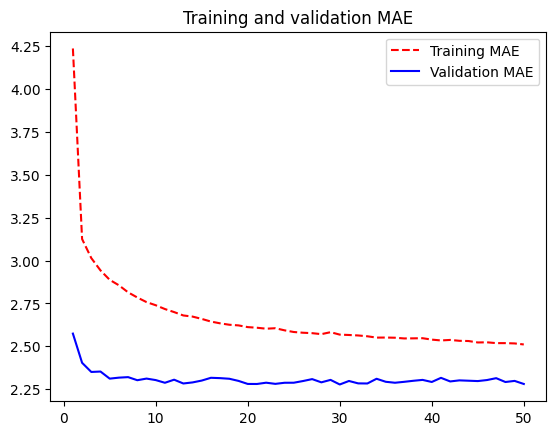

In [28]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [29]:
# Stacking reccurent layers

In [30]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_stacked_gru_dropout.keras")

print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 278s 334ms/step - loss: 28.1936 - mae: 3.9339 - val_loss: 10.5850 - val_mae: 2.4774
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 324s 336ms/step - loss: 15.0268 - mae: 2.9959 - val_loss: 9.3196 - val_mae: 2.3538
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 273s 333ms/step - loss: 14.0544 - mae: 2.9033 - val_loss: 8.8298 - val_mae: 2.3055
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 274s 334ms/step - loss: 13.4914 - mae: 2.8470 - val_loss: 8.9084 - val_mae: 2.3209
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 275s 335ms/step - loss: 13.0703 - mae: 2.7992 - val_loss: 8.7596 - val_mae: 2.3019
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 275s 335ms/step - loss: 12.5772 - mae: 2.7506 - val_loss: 8.5000 - val_mae: 2.2627
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 273s 333ms/step - loss: 12.2563 - mae: 2.7136 - val_loss: 8.4777 - val_mae: 2.2596
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 326s 338ms/step - loss: 11.8851 - mae: 2.6737 - val_loss: 8.4177 - val_mae: 2.2496
Epoch 9/50
819/

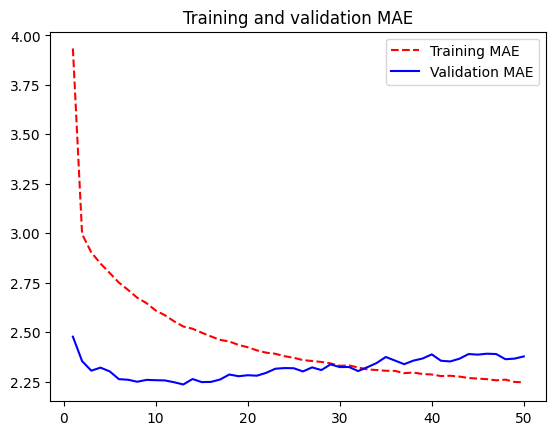

In [31]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [32]:
# Using bidirectional RNNs

In [34]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.Bidirectional(layers.LSTM(16))(inputs)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 153s 183ms/step - loss: 31.1961 - mae: 4.0326 - val_loss: 12.4917 - val_mae: 2.7342
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 151s 184ms/step - loss: 11.2764 - mae: 2.6160 - val_loss: 11.1904 - val_mae: 2.6051
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 153s 186ms/step - loss: 9.8252 - mae: 2.4418 - val_loss: 10.7534 - val_mae: 2.5703
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 155s 189ms/step - loss: 8.9261 - mae: 2.3214 - val_loss: 10.6124 - val_mae: 2.5357
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 152s 185ms/step - loss: 8.2366 - mae: 2.2311 - val_loss: 10.3930 - val_mae: 2.5048
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 152s 185ms/step - loss: 7.7717 - mae: 2.1652 - val_loss: 10.4993 - val_mae: 2.5098
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 151s 184ms/step - loss: 7.5015 - mae: 2.1269 - val_loss: 10.2526 - val_mae: 2.4820
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 151s 184ms/step - loss: 7.4967 - mae: 2.1276 - val_loss: 10.1970 - val_mae: 2.4845
Epoch 9/10
819

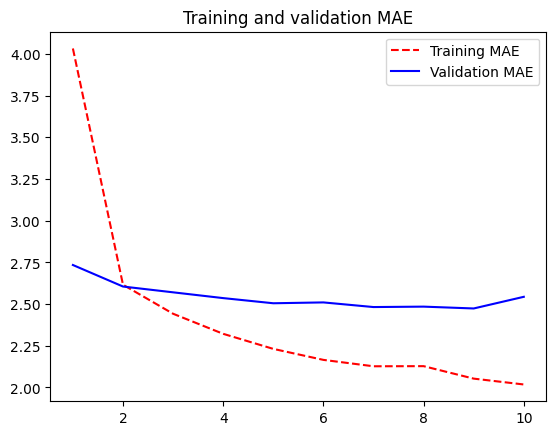

In [35]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()